In [7]:
from utils import get_svamp_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
import pandas as pd
df = get_svamp_df("ReWOO")

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


# Misclassified

In [8]:
df_misc = get_svamp_df("ReWOO", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "ID": "count",
}).reset_index().sort_values(by="ID", ascending=False).head(50)

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Model,Error Class,ID
1,gemma3:1b,Misclassified,8
0,deepseek-r1:1.5b,Misclassified,7
2,qwen2.5:0.5b,Misclassified,6
4,smollm2:360m,Misclassified,3
3,qwen3:0.6b,Misclassified,2


In [9]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 26
Total examples: 2556
Overall misclassification rate: 1.02%


# Accuracy

## Sorted

In [18]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc["is_correct"] = df_acc["is_correct"] * 100
df_acc

,Model,is_correct
7,qwen3:1.7b,93.309859
1,gemma-3-27b-it,88.028169
0,deepseek-r1:1.5b,86.619718
6,qwen3:0.6b,59.507042
5,qwen2.5:0.5b,28.521127
2,gemma3:1b,27.464789
3,llama3.2:1b,23.239437
8,smollm2:360m,15.140845
4,qwen2-math:1.5b,1.056338


In [19]:
print(df_acc.to_latex(index=False, caption='Genauigkeit der Modelle für SVAMP', label='tab:svamp_accuracy'))

\begin{table}
\caption{Genauigkeit der Modelle für SVAMP}
\label{tab:svamp_accuracy}
\begin{tabular}{ll}
\toprule
Model & is_correct \\
\midrule
qwen3:1.7b & 93.309859 \\
gemma-3-27b-it & 88.028169 \\
deepseek-r1:1.5b & 86.619718 \\
qwen3:0.6b & 59.507042 \\
qwen2.5:0.5b & 28.521127 \\
gemma3:1b & 27.464789 \\
llama3.2:1b & 23.239437 \\
smollm2:360m & 15.140845 \\
qwen2-math:1.5b & 1.056338 \\
\bottomrule
\end{tabular}
\end{table}



## Alphabetical

In [22]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.880282
1,ollama/deepseek-r1_1.5b,0.866197
2,ollama/gemma3_1b,0.274648
3,ollama/llama3.2_1b,0.232394
4,ollama/qwen2-math_1.5b,0.010563
5,ollama/qwen2.5_0.5b,0.285211
6,ollama/qwen3_0.6b,0.59507
7,ollama/qwen3_1.7b,0.933099
8,ollama/smollm2_360m,0.151408


In [23]:
acc_records = df_acc.to_records()

n = df["ID"].nunique()
significant_results = []
for i in range(len(acc_records)):
    model1 = acc_records[i][1]
    score1 = acc_records[i][2]
    for j in range(len(acc_records)):
        if i == j:
            continue
        model2 = acc_records[j][1]
        score2 = acc_records[j][2]

        result = compare_accuracies_v3(score1, n, score2, n)
        if result.is_significant:
            if score1 < score2:
                model1, model2 = model2, model1
                score1, score2 = score2, score1
            entry = (model1, model2, score1, score2, result.p_value, result.is_significant)
            if entry not in significant_results:
                significant_results.append(entry)

significant_results_df = pd.DataFrame([
    {
        'Model1': model1,
        'Model2': model2,
        'Score1': score1,
        'Score2': score2,
        'p_value': p_value,
        'is_significant': is_significant
    }
    for model1, model2, score1, score2, p_value, is_significant in significant_results
])
significant_results_df.sort_values(by="Model1", ascending=True)

,Model1,Model2,Score1,Score2,p_value,is_significant
0,google/gemma-3-27b-it,ollama/gemma3_1b,0.880282,0.274648,0.000000e+00,True
4,google/gemma-3-27b-it,ollama/qwen3_0.6b,0.880282,0.595070,2.220446e-16,True
3,google/gemma-3-27b-it,ollama/qwen2.5_0.5b,0.880282,0.285211,0.000000e+00,True
18,google/gemma-3-27b-it,ollama/smollm2_360m,0.880282,0.151408,0.000000e+00,True
1,google/gemma-3-27b-it,ollama/llama3.2_1b,0.880282,0.232394,0.000000e+00,True
2,google/gemma-3-27b-it,ollama/qwen2-math_1.5b,0.880282,0.010563,0.000000e+00,True
7,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,0.866197,0.274648,0.000000e+00,True
8,ollama/deepseek-r1_1.5b,ollama/llama3.2_1b,0.866197,0.232394,0.000000e+00,True
10,ollama/deepseek-r1_1.5b,ollama/qwen2.5_0.5b,0.866197,0.285211,0.000000e+00,True
11,ollama/deepseek-r1_1.5b,ollama/qwen3_0.6b,0.866197,0.595070,2.042810e-14,True


Interpreation

* **Gemma3 27B and Deepseek**: outperform all other models signifantly but underperforms *Qwen3 1.7B* significantly
* **Qwen2.5 Math** is outperformed by all other models
* **Qwen3 0.6B** outperforms *Gemma 1B*, *Llama*, and *Qwen2.5 0.5B* but underperforms *Qwen3 1.7B* and *Gemma3 27B*
* **Qwen3 1.7B** outperforms all models significantly excep *Gemma 27B*
* **Qwen3 1.7B** does **not** outperform **Gemma 27B** significantly

# Error Analysis

## Overview

In [20]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "ID": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="ID",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type              Model   Execution Error                           \
Error Class                   Calculation Error Declines to Answer  Loop   
0            deepseek-r1:1.5b               1.0                0.0   0.0   
1              gemma-3-27b-it               0.0                0.0   1.0   
2                   gemma3:1b               0.0                0.0   2.0   
3                 llama3.2:1b               0.0                8.0   0.0   
4             qwen2-math:1.5b               0.0                0.0   0.0   
5                qwen2.5:0.5b               0.0                0.0   0.0   
6                  qwen3:0.6b               0.0                0.0  20.0   
7                  qwen3:1.7b               0.0                0.0   2.0   
8                smollm2:360m               0.0                0.0   1.0   

Error Type                                    Structural Error  \
Error Class Overthinking Wrong Reasoning Equation Format Error   
0                    0.0            13.0                   2.0   
1                    0.0            32.0                   0.0   
2                    0.0           172.0                   0.0   
3                    0.0           118.0                   0.0   
4                    0.0             0.0                   0.0   
5                    0.0           168.0                   0.0   
6                   18.0            39.0                  24.0   
7                    2.0            13.0                   0.0   
8                    0.0           133.0                   0.0   

Error Type                                                 Tool Error  \
Error Class Plan Format Error Plan-Solve Mismatch Tool + Format Error   
0                        14.0                 5.0                 2.0   
1                         1.0                 0.0                 0.0   
2                         2.0                23.0                 0.0   
3                         5.0                70.0                 0.0   
4                       281.0                 0.0                 0.0   
5                         2.0                27.0                 0.0   
6                         2.0                16.0                 0.0   
7                         0.0                 2.0                 0.0   
8                        93.0                 2.0                12.0   

Error Type              
Error Class Tool Error  
0                  1.0  
1                  0.0  
2                  7.0  
3                 17.0  
4                  0.0  
5                  6.0  
6                  0.0  
7                  0.0  
8                  0.0

## Plots

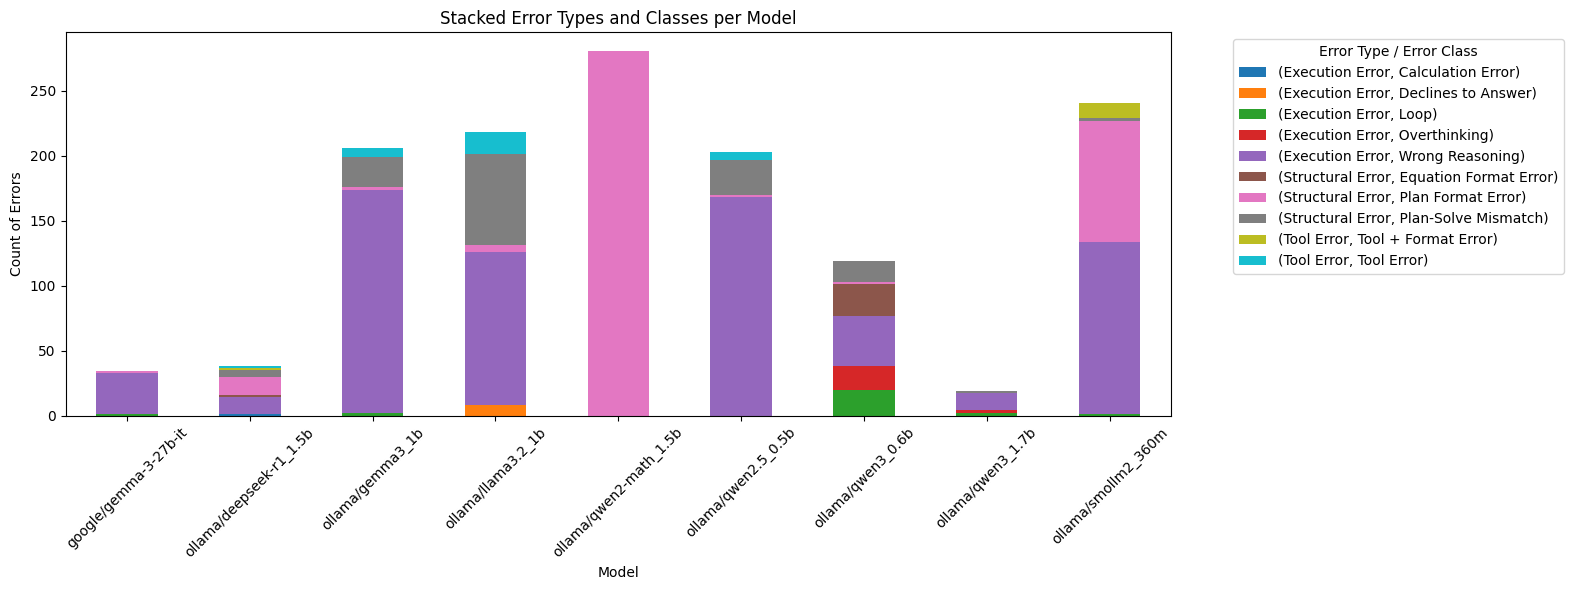

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Per Operation Type

In [26]:
# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Type'] not in question_type_mapping:
                question_type_mapping[row['Type']] = 0
            question_type_mapping[row['Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

# Convert to a DataFrame for better visualization
question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

,Question Type,Count
0,Subtraction,153
3,Addition,55
1,Common-Division,44
2,Multiplication,32


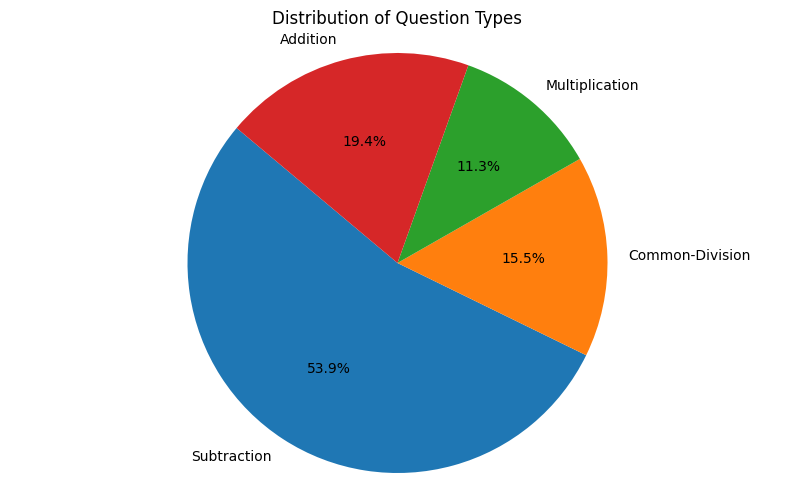

In [27]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [28]:
qtypes_df = df.groupby(["Model", "Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100

# Pivot the DataFrame to get question types as rows and models as columns
qtypes_pivot = qtypes_df.pivot_table(index='Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_65552/4148216791.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Type', columns='Model', values='Correct_Score', fill_value=0)


Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_360m
Type,,,,,,,,,
Addition,87.272727,90.909091,21.818182,18.181818,1.818182,20.000000,67.272727,92.727273,10.909091
Common-Division,81.818182,86.363636,31.818182,27.272727,0.000000,40.909091,54.545455,93.181818,13.636364
Multiplication,93.750000,81.250000,18.750000,9.375000,3.125000,37.500000,50.000000,93.750000,9.375000
Subtraction,88.888889,86.274510,30.065359,26.797386,0.653595,26.143791,60.130719,93.464052,18.300654


In [29]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df

,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/llama3.2_1b,Common-Division,27.272727,Multiplication,9.375000,0.034454,True
1,ollama/llama3.2_1b,Multiplication,9.375000,Subtraction,26.797386,0.005493,True
2,ollama/qwen2.5_0.5b,Addition,20.000000,Common-Division,40.909091,0.022551,True


Interpretation:

* **Qwen2.5:0.5B**: performs significantly better on *Common-Division* than on *Addition*
* **Llama**: performs significantly worse on *Multiplication* than on *Common Division* or *Subtraction*



## Question Type

In [30]:
# Different question types
def classify_question_type(question):
    if "how many more" in question.lower():
        return "How Many More"
    elif "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "how big" in question.lower():
        return "How Big"
    elif "how long" in question.lower():
        return "How Long"
    elif "what is" in question.lower():
        return "What is"
    elif "how deep" in question.lower():
        return "How Deep"
    elif "how far" in question.lower():
        return "How Far"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['Question-only'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Many More,75
2,How Much,33
3,How Big,3
4,What is,2
5,How Long,2
7,How Far,2
6,How Deep,1


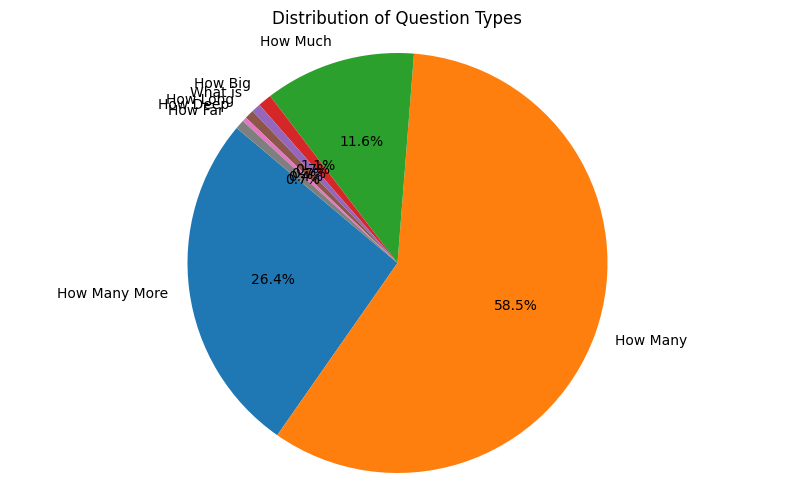

In [31]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [32]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_65552/3781238049.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)


Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_360m
Question_Type,,,,,,,,,
How Big,100.000000,66.666667,33.333333,66.666667,0.000000,100.000000,66.666667,100.000000,0.000000
How Deep,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,0.000000
How Far,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,0.000000
How Long,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,50.000000,100.000000,0.000000
How Many,88.554217,87.951807,27.108434,21.686747,1.807229,31.325301,62.048193,92.168675,15.060241
How Many More,84.000000,85.333333,25.333333,20.000000,0.000000,18.666667,52.000000,97.333333,20.000000
How Much,90.909091,81.818182,36.363636,36.363636,0.000000,30.303030,60.606061,87.878788,6.060606
What is,100.000000,100.000000,50.000000,50.000000,0.000000,100.000000,50.000000,100.000000,50.000000


In [33]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 1.0 (n=3) with 0.3132530120481928 (n=166) for model ollama/qwen2.5_0.5b
Comparing 1.0 (n=3) with 0.18666666666666668 (n=75) for model ollama/qwen2.5_0.5b
Comparing 1.0 (n=3) with 0.30303030303030304 (n=33) for model ollama/qwen2.5_0.5b
Comparing 0.3132530120481928 (n=166) with 0.18666666666666668 (n=75) for model ollama/qwen2.5_0.5b
Comparing 0.18666666666666668 (n=75) with 1.0 (n=2) for model ollama/qwen2.5_0.5b
Comparing 0.2 (n=75) with 0.06060606060606061 (n=33) for model ollama/smollm2_360m


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/qwen2.5_0.5b,How Big,100.000000,How Many,31.325301,0.033199,True
1,ollama/qwen2.5_0.5b,How Big,100.000000,How Many More,18.666667,0.008938,True
2,ollama/qwen2.5_0.5b,How Big,100.000000,How Much,30.303030,0.040056,True
3,ollama/qwen2.5_0.5b,How Many,31.325301,How Many More,18.666667,0.028030,True
4,ollama/qwen2.5_0.5b,How Many More,18.666667,What is,100.000000,0.041012,True
5,ollama/smollm2_360m,How Many More,20.000000,How Much,6.060606,0.024830,True


Interpretation

- **Qwen 2.5 0.5B**: Performs significantly worse on *How many more* than on *how many*
- **Qwen 3 1.7B**: Performs slightly but significantly worse on *How many* and *How much* than on *how many more*
- **SmolLM2:360M**: Performs significantly worse on *How much* than on *How many more*

# Plans

In [37]:
df_plans = get_svamp_df("ReWOO", include=["model_history"])

def get_plan_counter(model_history):
    try:
        history = eval(model_history)
        number_plans = len(history[0]["plan"]["steps"])
    except Exception:
        number_plans = 0
    return number_plans

df_plans['Plan_Counter'] = df_plans['model_history'].apply(get_plan_counter)
df_plans['Plan_Used'] = df_plans['Plan_Counter'] > 0

df_plans.groupby(['Model']).agg({
    'Plan_Counter': 'sum',
    'Plan_Used': 'mean',
    'is_correct': 'mean'
})

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Plan_Counter,Plan_Used,is_correct
Model,,,
google/gemma-3-27b-it,542,1.000000,0.880282
ollama/deepseek-r1_1.5b,397,0.957746,0.866197
ollama/gemma3_1b,539,1.000000,0.274648
ollama/llama3.2_1b,332,0.950704,0.232394
ollama/qwen2-math_1.5b,3,0.010563,0.010563
ollama/qwen2.5_0.5b,511,0.992958,0.285211
ollama/qwen3_0.6b,596,0.911972,0.59507
ollama/qwen3_1.7b,340,0.992958,0.933099
ollama/smollm2_360m,659,0.711268,0.151408


In [43]:
# Check if tool was used if it was correct
df_plans.groupby(['Model']).agg({
    'Plan_Counter': 'mean'
})

,Plan_Counter
Model,
google/gemma-3-27b-it,1.908451
ollama/deepseek-r1_1.5b,1.397887
ollama/gemma3_1b,1.897887
ollama/llama3.2_1b,1.169014
ollama/qwen2-math_1.5b,0.010563
ollama/qwen2.5_0.5b,1.799296
ollama/qwen3_0.6b,2.098592
ollama/qwen3_1.7b,1.197183
ollama/smollm2_360m,2.320423


# Plan vs Solve

In [46]:
from math_datasets.datasets import Dataset
import re

df_plan_vs_solve = get_svamp_df("ReWOO", include=["model_history"])

def check_solve_reasoning(reasoning: str) -> bool:
    splits = reasoning.split("---------------------------------")
    # remove #E1 = and #E2 = from the equations with regex
    equations = re.sub(r"#E\d+ = ", "", splits[1].strip())
    equation_results = equations.split("\n")
    equation_results = [Dataset.extract_answer(eq.strip()) for eq in equation_results]
    solve = splits[-1].strip()
    float_solve = Dataset.extract_answer(solve)
    if float_solve is None:
        return False
    return float_solve in equation_results


df_plan_vs_solve["plan_vs_solve"] = df_plan_vs_solve["reasoning"].apply(check_solve_reasoning)
df_plan_vs_solve.groupby(["Model", "plan_vs_solve"]).agg({
    "is_correct": "mean",
    "ID": "count"
})

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


is_correct   ID
Model                   plan_vs_solve                
google/gemma-3-27b-it   False                0.0    4
                        True            0.892857  280
ollama/deepseek-r1_1.5b False           0.573529   68
                        True            0.958333  216
ollama/gemma3_1b        False           0.186047  172
                        True            0.410714  112
ollama/llama3.2_1b      False           0.103139  223
                        True            0.704918   61
ollama/qwen2-math_1.5b  False           0.003546  282
                        True                 1.0    2
ollama/qwen2.5_0.5b     False           0.167832  143
                        True            0.404255  141
ollama/qwen3_0.6b       False           0.282051  117
                        True            0.814371  167
ollama/qwen3_1.7b       False           0.867647   68
                        True            0.953704  216
ollama/smollm2_360m     False           0.112613  222
                        True            0.290323   62

How to read this table:

* If the solve answer is based on the plan, what is the accuracy then
    * If the accuracy is low, this suggests wrong reasoning in the plan
* If the solve answer is not based on the plan
    * and the accuracy is high, this means the solve rethinks the wrong plan and provides the correct answer
    * it says nothing about the correctness of the plan (connect with AutoSolve: AutoSolve underperforms)

# Auto Solve

In [44]:
from math_datasets.generators.rewoo_v1 import PlanExecutor
from math_datasets.datasets import Dataset

df_auto_solve = get_svamp_df("ReWOO", include=["model_history"])
plan_executor = PlanExecutor()

def execute_plan(model_history):
    try:
        # parse the model history as list of dictionaries
        if isinstance(model_history, str):
            model_history = eval(model_history)

        plan_str = model_history[0]["plan"]["plan_string"]
        return plan_executor.follow_plan(plan_str)[-1]["solve"]["result"]
    except Exception as e:
        return None

df_auto_solve["AutoSolve"] = df_auto_solve["model_history"].apply(execute_plan)

def extract_answer(answer):
    if answer is None:
        return None
    return Dataset.extract_answer(answer)

df_auto_solve["target_answer_float"] = df_auto_solve["target_answer"].apply(extract_answer)
df_auto_solve["AutoSolve_float"] = df_auto_solve["AutoSolve"].apply(extract_answer)

df_auto_solve["AutoSolve_correct"] = df_auto_solve["AutoSolve_float"] == df_auto_solve["target_answer_float"]
df_auto_solve["AutoSolve_correct"].value_counts(), df_auto_solve["is_correct"].value_counts()
df_auto_solve.groupby(["Model"]).agg({
    "AutoSolve_correct": "mean",
    "is_correct": "mean",
    "ID": "count"
})

/opt/miniconda3/envs/MA312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MPS (Metal Performance Shaders) is available! Using Apple Silicon GPU.
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,AutoSolve_correct,is_correct,ID
Model,,,
google/gemma-3-27b-it,0.869718,0.880282,284
ollama/deepseek-r1_1.5b,0.676056,0.866197,284
ollama/gemma3_1b,0.239437,0.274648,284
ollama/llama3.2_1b,0.394366,0.232394,284
ollama/qwen2-math_1.5b,0.007042,0.010563,284
ollama/qwen2.5_0.5b,0.257042,0.285211,284
ollama/qwen3_0.6b,0.172535,0.59507,284
ollama/qwen3_1.7b,0.528169,0.933099,284
ollama/smollm2_360m,0.021127,0.151408,284


Interpretation:

* Only for **Llama** the AutoSolve significantly outperforms which suggests lacking in solver capability
* **Gemma 27B** and **Qwen 2.5 0.5B** perform on par
* All other models significantly underperform with AutoSolve